### Path Finder: What are the potential paths between two nodes?
### This pipeline can be used to get a ranked path between A and B given a set of paths.
### This pipeline requires users to set the categories of intermediate nodes for their pipeline

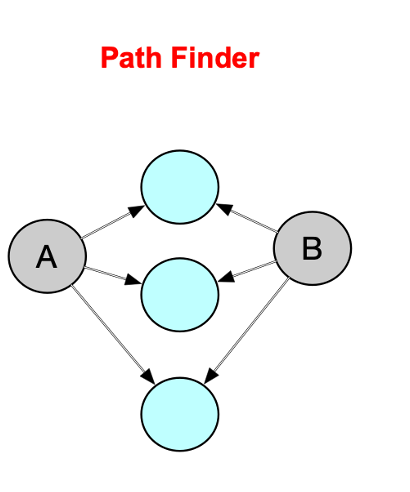


In [11]:
# This if for internal use only. Users need to clone the Translator_component_toolkit repo and install TCT and its dependencies in their local environment to run the code below.
import sys
import os
sys.path.append('../TCT/')
import TCT
import translator_kpinfo
import node_normalizer
import name_resolver
import translator_metakg
import translator_query
import TCT_pathfinder

import requests

ModuleNotFoundError: No module named 'TCT_pathfinder'

In [3]:
# This is for public use. Users need to install TCT and its dependencies in their local environment to run the code below.
from TCT import TCT

from TCT import name_resolver
from TCT import translator_metakg
from TCT import translator_kpinfo
from TCT import translator_query


import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import requests
import json
import pandas as pd
import  seaborn as sns
import networkx as nx
import numpy as np
import ipycytoscape
import yaml


In [4]:
APInames, metaKG, Translator_KP_info= translator_metakg.load_translator_resources()

All_predicates = list(set(metaKG['Predicate']))
All_categories = list((set(list(set(metaKG['Subject']))+list(set(metaKG['Object'])))))
API_withMetaKG = list(set(metaKG['API']))

    # generate a dictionary of API and its predicates
API_predicates = {}
for api in API_withMetaKG:
    API_predicates[api] = list(set(metaKG[metaKG['API'] == api]['Predicate']))

Skipping server without x-maturity: {'url': '/sipr'}


In [5]:
# select a list of APIs to use and a list of predicates to use
selected_APIlist = []

if len(selected_APIlist) == 0:
    select_APIs = APInames
else:
    select_APIs = {k: APInames[k] for k in selected_APIlist if k in APInames}

selected_metaKG = metaKG[metaKG['API'].isin(select_APIs.keys())]
#print(select_APIs)
print(selected_metaKG.shape)


(22568, 5)


In [6]:
name_resolver.lookup('miR-155', only_taxa='NCBITaxon:9606')

TranslatorNode(curie='NCBIGene:406947', label='MIR155', types=['biolink:Gene', 'biolink:GeneOrGeneProduct', 'biolink:GenomicEntity', 'biolink:ChemicalEntityOrGeneOrGeneProduct', 'biolink:PhysicalEssence', 'biolink:OntologyClass', 'biolink:BiologicalEntity', 'biolink:ThingWithTaxon', 'biolink:NamedThing', 'biolink:Entity', 'biolink:PhysicalEssenceOrOccurrent', 'biolink:MacromolecularMachineMixin'], synonyms=None, curie_synonyms=None, attributes=None, taxa=['NCBITaxon:9606'])

PUBCHEM.COMPOUND:132212657
MONDO:0018874
RTX KG2 - TRAPI 1.5.0: Success!
CATRAX Pharmacogenomics KP - TRAPI 1.5.0: Success!
Automat-monarchinitiative(Trapi v1.5.0): Success!
Automat-pharos(Trapi v1.5.0): Success!
CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0: Success!
BioThings Explorer (BTE) TRAPI: Success!
Automat-robokop(Trapi v1.5.0): Success!
RTX KG2 - TRAPI 1.5.0: Success!
Clinical Trials KP - TRAPI 1.5.0: Success!
NodeNorm does not know about these identifiers: NCBIGene:130064183,NCBIGene:126861451,NCBIGene:126807619,NCBIGene:130056381,NCBIGene:110806263,NCBIGene:129934333,NCBIGene:107303340
Number of possible paths:  2


/Users/gqin/Github_repo/Translator_component_toolkit/TCT/TCT.py:1639: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=fontsize)


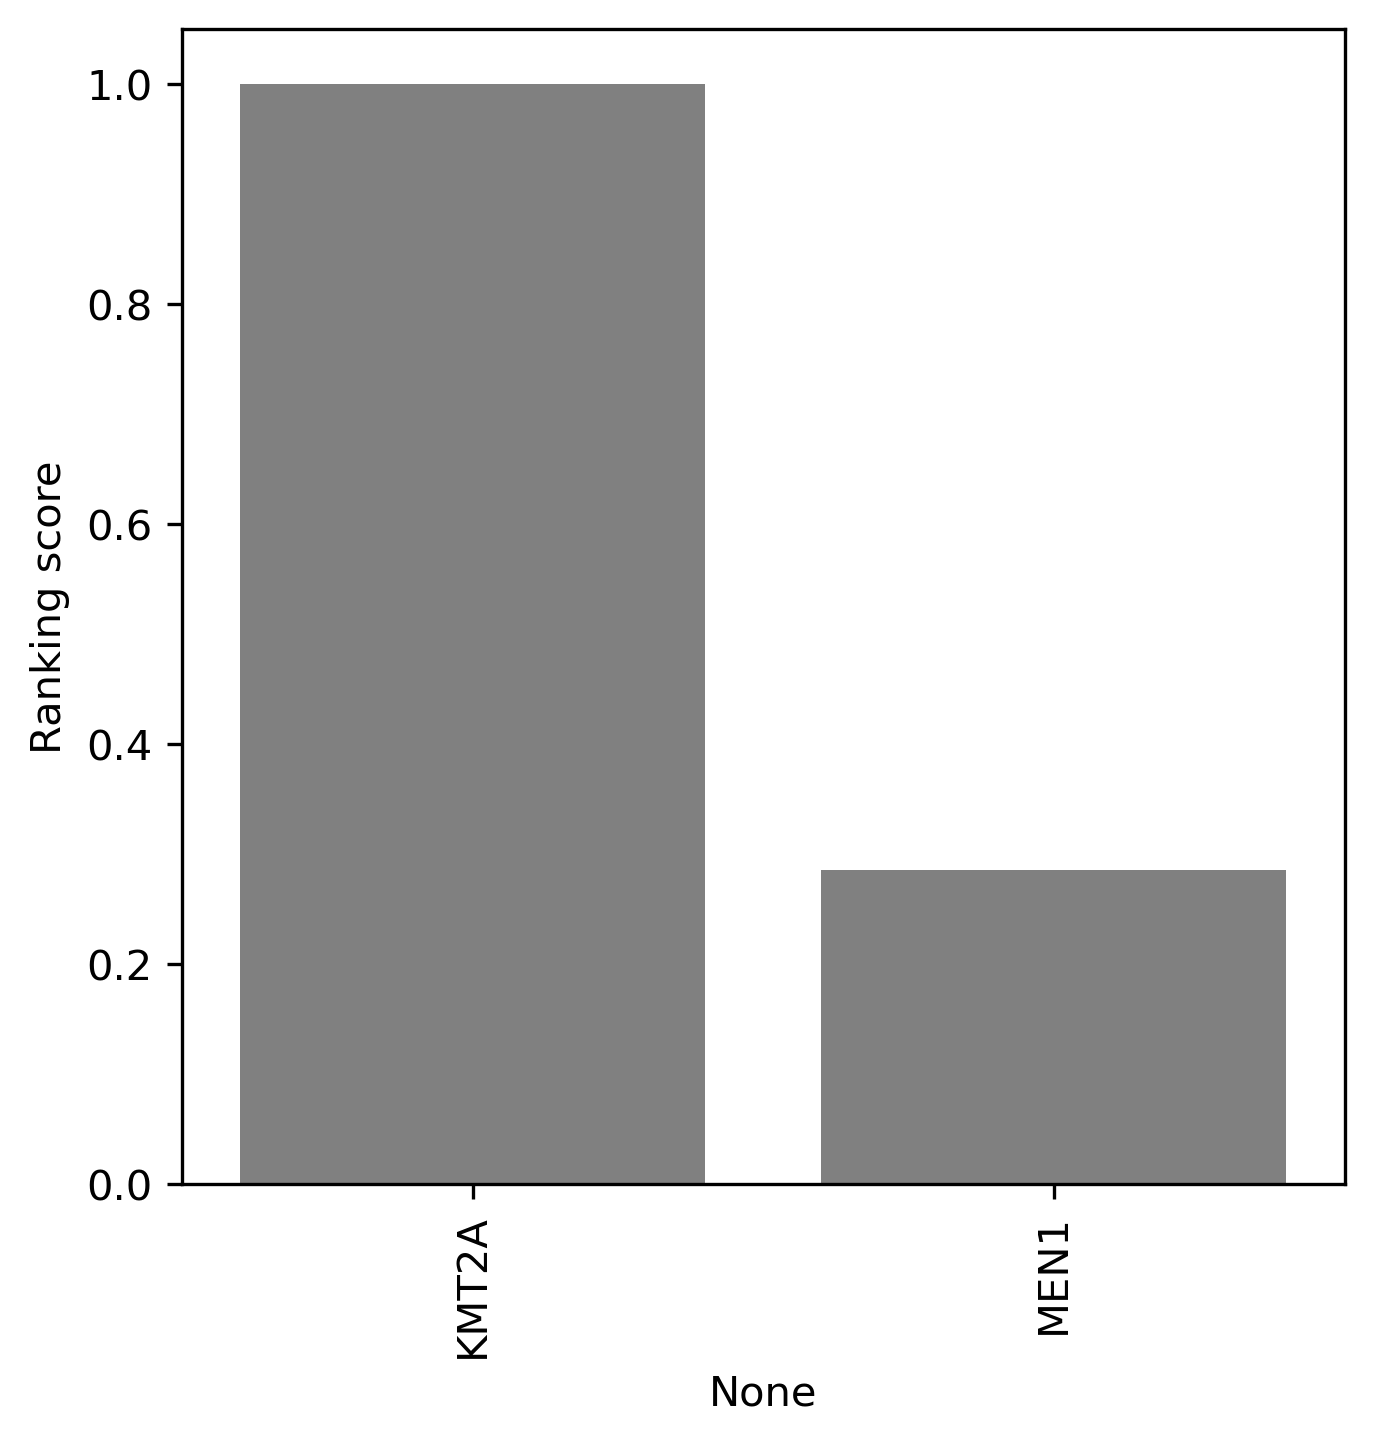

In [7]:
paths, input_node1_id, input_node2_id, result1, result2, result_parsed1, result_parsed2, result_ranked_by_primary_infores1, result_ranked_by_primary_infores2 = TCT.Path_finder(input_node1='PUBCHEM.COMPOUND:132212657', #IFNG
                                                                                                                                                                                input_node2= 'MONDO:0018874', #COVID-19
                                                                                                                                                                                intermediate_categories=['biolink:Protein', 'biolink:Gene' ], 
                                                                                                                                                                                APInames=select_APIs, 
                                                                                                                                                                                metaKG=selected_metaKG, 
                                                                                                                                                                                API_predicates=API_predicates)

In [8]:
response = dict()
response['knowledge_graph'] = {**result1, **result2}  # combine result1 and result2 into a knowledge graph


In [10]:
path_finder_result = parse_results_for_pathfinder('PUBCHEM.COMPOUND:132212657', 'MONDO:0018874', result1=result1, result2=result2)

NameError: name 'parse_results_for_pathfinder' is not defined

In [97]:
response['auxiliary_graphs'] = dict()
result_nodes = dict()
for key1 in result1.keys():
   # print(key1)
    #print(result1[key1])
    subject1 = result1[key1]['subject']
    object1 = result1[key1]['object']
    if subject1 == input_node1_id:
        intermediate_node = object1
    else:        
        intermediate_node = subject1

    for key2 in result2.keys():
        subject2 = result2[key2]['subject']
        object2 = result2[key2]['object']
        if intermediate_node == subject2 or intermediate_node == object2:
            if intermediate_node not in result_nodes:
                result_nodes[intermediate_node] = []
                result_id += 1
                result_nodes[intermediate_node].append(key1)
                result_nodes[intermediate_node].append(key2)
            else:
                result_nodes[intermediate_node].append(key1)
                result_nodes[intermediate_node].append(key2)
result_id = 0
for intermediate_node in result_nodes.keys():
    result_id += 1
    path = result_nodes[intermediate_node]
    response['auxiliary_graphs']['a_{}'.format(result_id)] = {'edges': path}
    


In [101]:
result_nodes

{'NCBIGene:4221': ['3304222', '22618021', '3304222', '44910002'],
 'NCBIGene:4297': ['3610325',
  'e_125',
  '3610325',
  'e_136',
  '3610325',
  'e_247',
  '3610325',
  'e_381',
  '3610325',
  '493aeb09',
  '3610325',
  '7bf4847f',
  '3610325',
  'ed34ff22',
  '3610325',
  '0203d18e',
  '3610325',
  '45409016',
  '3610325',
  '46238783',
  '3610325',
  '7740001',
  '3610325',
  '7740034',
  '3610325',
  'db1e5b6ee01b39c60d85be8038d2d465',
  '3610325',
  '83587c28a50e43a41a4e405607f3fda3',
  '3610325',
  'b0329bcde7a73fec6aefbb1badc47ca2',
  '3610325',
  'a12736d4e396684451231bb41021c499',
  '3610325',
  'e00c271ef3cd60cdb58bf1a0c3156617',
  '3610325',
  'NCBIGene:4297-gene_associated_with_condition-MONDO:0018874-via_subclass']}

In [98]:
response['auxiliary_graphs']

{'a_1': {'edges': ['3304222', '22618021', '3304222', '44910002']},
 'a_2': {'edges': ['3610325',
   'e_125',
   '3610325',
   'e_136',
   '3610325',
   'e_247',
   '3610325',
   'e_381',
   '3610325',
   '493aeb09',
   '3610325',
   '7bf4847f',
   '3610325',
   'ed34ff22',
   '3610325',
   '0203d18e',
   '3610325',
   '45409016',
   '3610325',
   '46238783',
   '3610325',
   '7740001',
   '3610325',
   '7740034',
   '3610325',
   'db1e5b6ee01b39c60d85be8038d2d465',
   '3610325',
   '83587c28a50e43a41a4e405607f3fda3',
   '3610325',
   'b0329bcde7a73fec6aefbb1badc47ca2',
   '3610325',
   'a12736d4e396684451231bb41021c499',
   '3610325',
   'e00c271ef3cd60cdb58bf1a0c3156617',
   '3610325',
   'NCBIGene:4297-gene_associated_with_condition-MONDO:0018874-via_subclass']}}

In [87]:

print(response.keys())

response['auxiliary_graphs']

dict_keys(['knowledge_graph', 'auxiliary_graphs'])


{'a_7': {'edges': ['3304222', '22618021', '3304222', '44910002']},
 'a_8': {'edges': ['3610325',
   'e_125',
   '3610325',
   'e_136',
   '3610325',
   'e_247',
   '3610325',
   'e_381',
   '3610325',
   '493aeb09',
   '3610325',
   '7bf4847f',
   '3610325',
   'ed34ff22',
   '3610325',
   '0203d18e',
   '3610325',
   '45409016',
   '3610325',
   '46238783',
   '3610325',
   '7740001',
   '3610325',
   '7740034',
   '3610325',
   'db1e5b6ee01b39c60d85be8038d2d465',
   '3610325',
   '83587c28a50e43a41a4e405607f3fda3',
   '3610325',
   'b0329bcde7a73fec6aefbb1badc47ca2',
   '3610325',
   'a12736d4e396684451231bb41021c499',
   '3610325',
   'e00c271ef3cd60cdb58bf1a0c3156617',
   '3610325',
   'NCBIGene:4297-gene_associated_with_condition-MONDO:0018874-via_subclass']}}

In [22]:
# load the result json file from a local path
with open('./Pathfinder_response_message.json', 'r') as f:
    example_response_message = json.load(f)

In [100]:
example_response_message.keys()

dict_keys(['query_graph', 'knowledge_graph', 'results', 'auxiliary_graphs'])

In [96]:
example_response_message['results'][0]['node_bindings']

{'SN': [{'id': 'NCBIGene:596', 'attributes': []}],
 'ON': [{'id': 'NCBIGene:3815', 'attributes': []}]}

In [105]:
example_response_message['knowledge_graph']['nodes']

{'NCBIGene:596': {'name': 'BCL2',
  'categories': ['biolink:Gene'],
  'attributes': [{'attribute_type_id': 'biolink:Attribute',
    'value': ['ENSEMBL:ENSG00000171791',
     'ENSEMBL:ENSP00000503628',
     'ENSEMBL:ENSP00000503628.1',
     'HGNC:990',
     'MESH:C000595707',
     'NCBIGene:596',
     'OMIM:151430',
     'PR:P10415',
     'UMLS:C0376515',
     'UMLS:C4042483',
     'UniProtKB:A0A7I2V3S7',
     'UniProtKB:P10415'],
    'original_attribute_name': 'equivalent_identifiers'},
   {'attribute_type_id': 'biolink:Attribute',
    'value': 84.8,
    'original_attribute_name': 'information_content'},
   {'attribute_type_id': 'biolink:Attribute',
    'value': 'BCL2 apoptosis regulator',
    'original_attribute_name': 'description'},
   {'attribute_type_id': 'biolink:Attribute',
    'value': ['NCBITaxon:9606'],
    'original_attribute_name': 'in_taxon'},
   {'attribute_type_id': 'biolink:Attribute',
    'value': 'Homo sapiens',
    'original_attribute_name': 'in_taxon_label'},
   {'a

In [38]:
#example_response_message['results'][0]['node_bindings']
#example_response_message['results'][0]['analyses']

In [ ]:
len(example_response_message['auxiliary_graphs'].keys())

1000

In [77]:
example_response_message['knowledge_graph']['edges']['urn:uuid:ff00b44d-74d5-4379-affb-e1a35123462a']

{'predicate': 'biolink:regulates',
 'subject': 'NCBIGene:3815',
 'object': 'NCBIGene:5295',
 'sources': [{'resource_id': 'infores:gandalf',
   'resource_role': 'aggregator_knowledge_source',
   'upstream_resource_ids': ['infores:signor']},
  {'resource_id': 'infores:signor',
   'resource_role': 'primary_knowledge_source',
   'upstream_resource_ids': []}],
 'qualifiers': [{'qualifier_type_id': 'biolink:qualified_predicate',
   'qualifier_value': 'biolink:causes'},
  {'qualifier_type_id': 'biolink:object_direction_qualifier',
   'qualifier_value': 'upregulated'},
  {'qualifier_type_id': 'biolink:object_aspect_qualifier',
   'qualifier_value': 'activity'}],
 'attributes': [{'attribute_type_id': 'biolink:knowledge_level',
   'value': 'knowledge_assertion',
   'original_attribute_name': 'knowledge_level'},
  {'attribute_type_id': 'biolink:agent_type',
   'value': 'manual_agent',
   'original_attribute_name': 'agent_type'},
  {'attribute_type_id': 'biolink:original_subject',
   'value': 'Uni

In [88]:
example_response_message['auxiliary_graphs']

{'a_69': {'edges': ['magma_NCBIGene:596_EFO:0004995NCBIGene:596EFO:0004995',
   'urn:uuid:706547ae-3694-43f4-bdc4-7a5a7327973a',
   'magma_NCBIGene:5295_EFO:0004995NCBIGene:5295EFO:0004995',
   'urn:uuid:4f4173fb-817a-4936-a1cc-a137d44c6ec9',
   'urn:uuid:ff00b44d-74d5-4379-affb-e1a35123462a'],
  'attributes': []},
 'a_140': {'edges': ['urn:uuid:5c6f709a-1200-4c76-97bd-f67b07aa2d6e',
   'urn:uuid:7f6c8274-8382-4d94-9700-1824adc59040',
   'urn:uuid:c8f71ea3-1648-424c-a118-8189fd12b95d'],
  'attributes': []},
 'a_154': {'edges': ['urn:uuid:33b60319-2a9d-4b7c-a40b-662b7c597d88',
   'urn:uuid:5c6f709a-1200-4c76-97bd-f67b07aa2d6e',
   'urn:uuid:2b381c61-5a62-4a5a-8345-a574edc8ddc8'],
  'attributes': []},
 'a_231': {'edges': ['urn:uuid:7e913350-222a-4723-a9bb-14e8fd3d246f',
   'urn:uuid:f28afe79-2296-41ea-b1c7-d212b12ee700',
   'urn:uuid:21bcff9b-cd9a-47c2-bfbc-bdf840a44031',
   'urn:uuid:442184fb-b47f-4412-82b6-dc2525e8d1db'],
  'attributes': []},
 'a_434': {'edges': ['urn:uuid:1e1d1c91-f92

In [7]:
intermediate_node = name_resolver.lookup('KMT2A', only_taxa='NCBITaxon:9606').curie



In [8]:
matches2 = []
for k in result2.keys():
    if input_node2_id == result2[k]['subject'] and intermediate_node == result2[k]['object']:
        matches2.append(result2[k])
    elif input_node2_id == result2[k]['object'] and intermediate_node == result2[k]['subject']:
        matches2.append(result2[k])

for k in matches2:
    print(k['sources'])

[{'resource_id': 'infores:diseases', 'resource_role': 'primary_knowledge_source'}, {'resource_id': 'infores:rtx-kg2', 'resource_role': 'aggregator_knowledge_source', 'upstream_resource_ids': ['infores:diseases']}]
[{'resource_id': 'infores:disgenet', 'resource_role': 'primary_knowledge_source'}, {'resource_id': 'infores:rtx-kg2', 'resource_role': 'aggregator_knowledge_source', 'upstream_resource_ids': ['infores:disgenet']}]
[{'resource_id': 'infores:semmeddb', 'resource_role': 'primary_knowledge_source'}, {'resource_id': 'infores:rtx-kg2', 'resource_role': 'aggregator_knowledge_source', 'upstream_resource_ids': ['infores:semmeddb']}]
[{'resource_id': 'infores:semmeddb', 'resource_role': 'primary_knowledge_source'}, {'resource_id': 'infores:rtx-kg2', 'resource_role': 'aggregator_knowledge_source', 'upstream_resource_ids': ['infores:semmeddb']}]
[{'resource_id': 'infores:ctd', 'resource_role': 'primary_knowledge_source'}, {'resource_id': 'infores:pharos', 'resource_role': 'aggregator_kno

In [9]:
matches = []
for k in result1.keys():
    if input_node1_id == result1[k]['subject'] and intermediate_node == result1[k]['object']:
        matches.append(result1[k])
    elif input_node1_id == result1[k]['object'] and intermediate_node == result1[k]['subject']:
        matches.append(result1[k])

for k in matches:
    print(k['sources'])

[{'resource_id': 'infores:ncit', 'resource_role': 'primary_knowledge_source'}, {'resource_id': 'infores:rtx-kg2', 'resource_role': 'aggregator_knowledge_source', 'upstream_resource_ids': ['infores:ncit']}]


In [13]:
import pandas as pd

# Create a DataFrame from the matches
df = pd.DataFrame(matches)

# Display the DataFrame
df

,attributes,object,predicate,sources,subject
0,"[{'attribute_source': 'infores:rtx-kg2', 'attr...",NCBIGene:4297,biolink:physically_interacts_with,"[{'resource_id': 'infores:ncit', 'resource_rol...",PUBCHEM.COMPOUND:132212657


In [12]:
forplot = TCT.visulize_path(input_node1_id, name_resolver.lookup('KMT2A', only_taxa='NCBITaxon:9606').curie, input_node2_id, result1, result2) 

CytoscapeWidget(cytoscape_layout={'name': 'cola', 'title': 'Path', 'nodeSpacing': 80, 'edgeLengthVal': 50}, cy…

# link to the UI
https://ui.ci.transltr.io/
